# Exploratory Data Analysis

In [ ]:
setwd("/Users/Local/statsproject")

In [1]:
source("src/functions_and_things.r")

load_libraries()

Warning message in file(filename, "r", encoding = encoding):
“cannot open file 'src/functions_and_things.r': No such file or directory”


ERROR: Error in file(filename, "r", encoding = encoding): cannot open the connection


In [ ]:
s_grey = "#7C858C"
s_blue = "#008EB7"

In [ ]:
df <- read.csv("data/processed/combined_data_weekly.csv")

df |>
  filter(week > "2024-06-06" & 
         week < "2025-05-31") -> df

head(df)

,week,borough,ridership,min_temp,rain,snow
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
1,2024-06-09,Bronx,1374644,63.42857,0.85,0
2,2024-06-09,Brooklyn,4459425,63.42857,1.70,0
3,2024-06-09,Manhattan,8296099,63.42857,1.70,0
4,2024-06-09,Queens,2961989,63.42857,0.85,0
5,2024-06-16,Bronx,1289483,67.28571,0.04,0
6,2024-06-16,Brooklyn,4367560,67.28571,0.08,0


## Plots

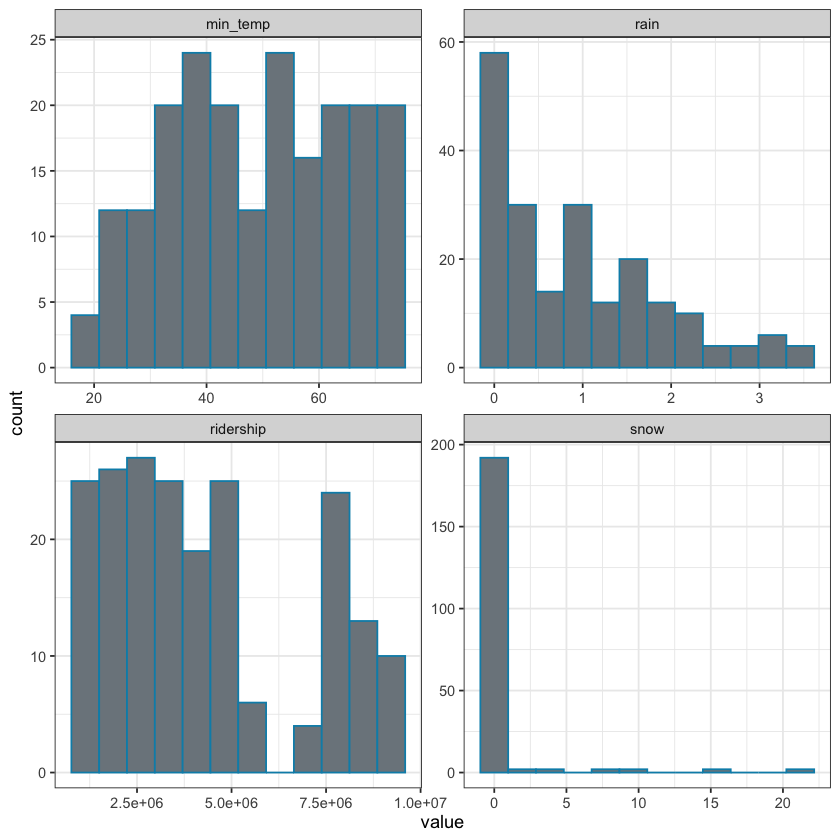

In [ ]:
# ref. classwork 2 

df |> 
    keep(is.numeric) |> 
    gather() |>
    ggplot(aes(x = value)) + 
    facet_wrap(~ key, scales = "free") +
    geom_histogram(bins = 12, color = s_blue, fill = s_grey) +
    theme_bw()

## Beginning time series 

In [ ]:
df$week = as.Date(df$week)

class(df$week)

[1] "Date"

In [ ]:
nrow(df)

[1] 204

In [ ]:
sum(is.na(df$ridership))

[1] 0

In [ ]:
n_distinct(df$week)

[1] 51

In [ ]:
df |> 
    arrange(week) |> 
    mutate(ridership_ma = rollmean(ridership, 14, fill = NA, align = "center")) -> df 

Warning message:
“Removed 13 rows containing missing values or values outside the scale range
(`geom_line()`).”


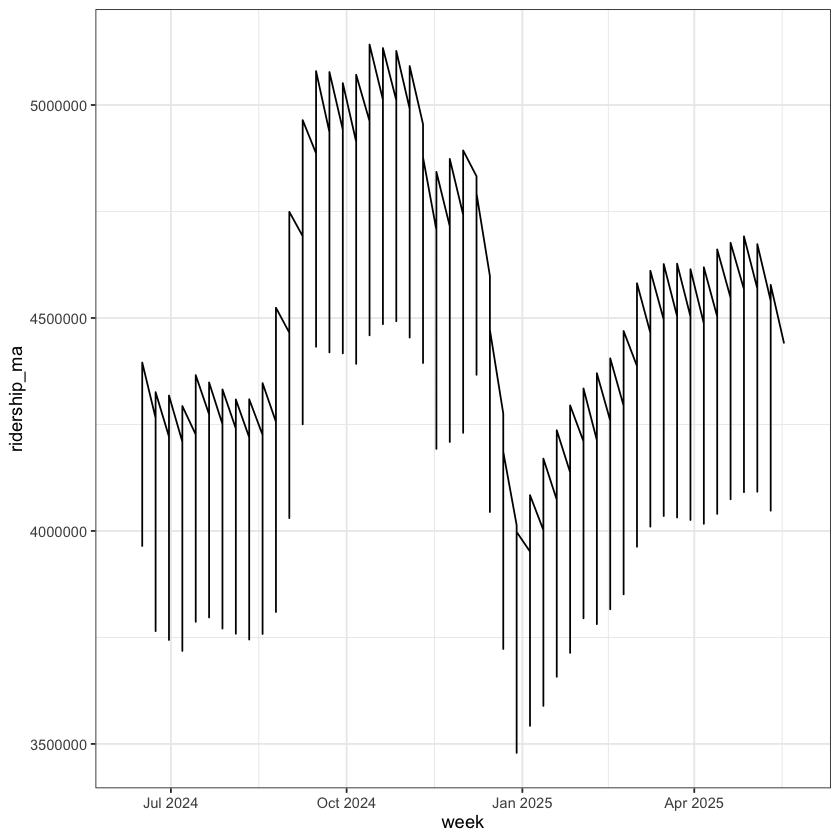

In [ ]:
ggplot(df, aes(x = week)) + 
    geom_line(aes(y = ridership_ma)) + 
    theme_bw()

In [ ]:
ggplot(df, aes(x = week, y = ridership, color = as.factor((coords_cbd)))) + 
    geom_line(lwd = 1) + theme_bw()

ERROR while rich displaying an object: Error in `geom_line()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! object 'coords_cbd' not found

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 

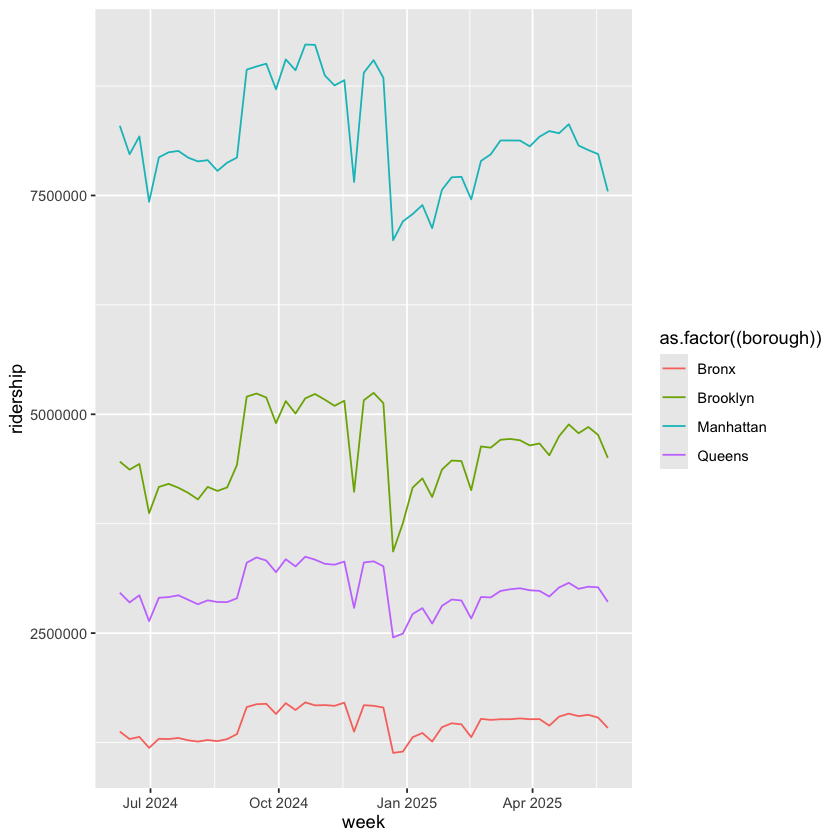

In [ ]:
ggplot(df, aes(x = week, y = ridership, color = as.factor((borough)))) + 
    geom_line()

## brooklyn 

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


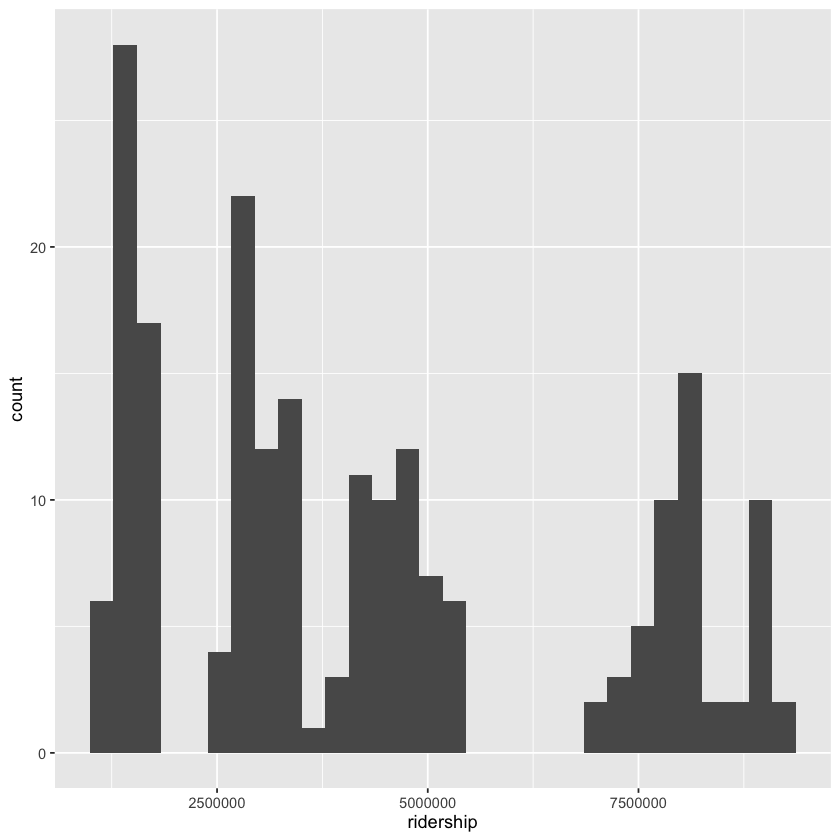

In [ ]:
ggplot(data = df, aes(x = ridership)) + geom_histogram()

,week,borough,ridership,min_temp,rain,snow,ridership_ma
,<date>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,2024-06-09,Brooklyn,4459425,63.42857,1.70,0,NA
2,2024-06-16,Brooklyn,4367560,67.28571,0.08,0,NA
3,2024-06-23,Brooklyn,4432437,67.85714,1.70,0,3764920
4,2024-06-30,Brooklyn,3869887,67.42857,1.36,0,3744135
5,2024-07-07,Brooklyn,4169863,72.42857,1.78,0,3718389
6,2024-07-14,Brooklyn,4204937,72.42857,2.06,0,3786827


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
3432033 4170108 4618641 4582669 4953282 5244600 

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


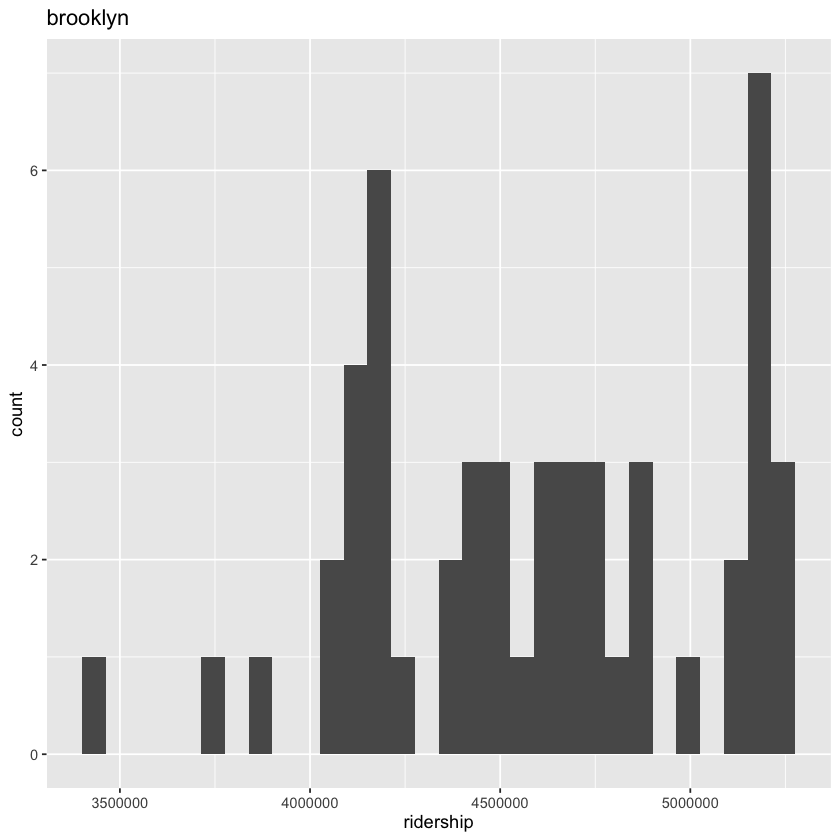

In [ ]:
df |> filter(borough == "Brooklyn") -> df_brooklyn 

head(df_brooklyn)

summary(df_brooklyn$ridership)

ggplot(data = df_brooklyn, aes(x = ridership)) + geom_histogram()  +
    labs(title = "brooklyn")

In [ ]:
row = which.min(df_brooklyn$ridership)
print(df_brooklyn[row, ])

df <- df[-row, ]

         week  borough ridership min_temp rain snow ridership_ma
29 2024-12-22 Brooklyn   3432033 25.57143 1.38    0      3723012


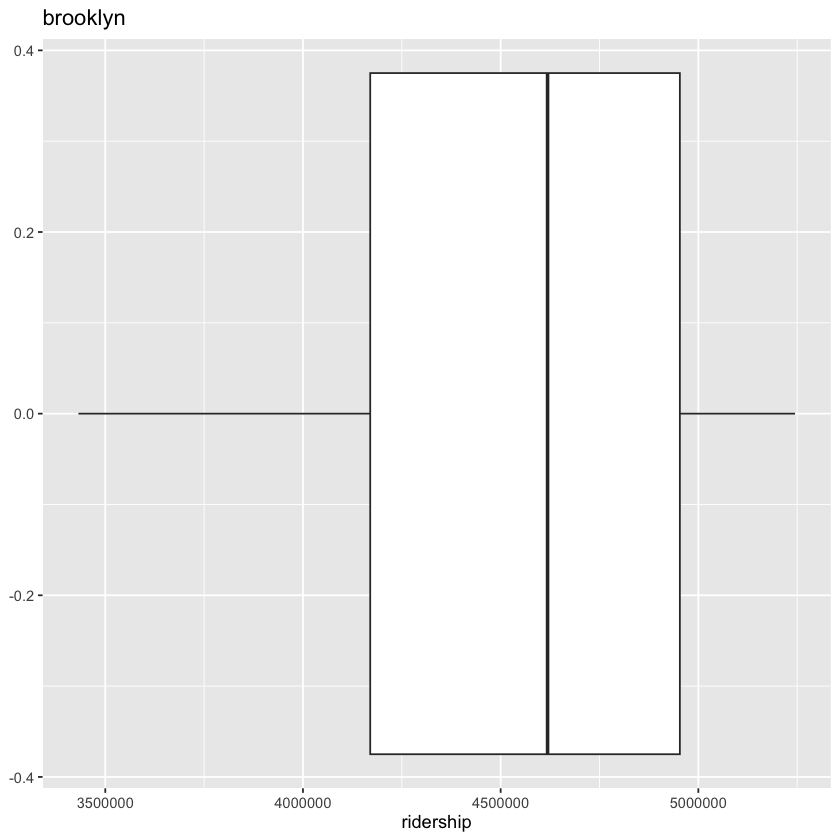

In [ ]:
ggplot(data = df_brooklyn, aes(x = ridership)) + geom_boxplot()  +
    labs(title = "brooklyn")